In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

# Create time axis
t = np.linspace(0, 1, 10)

# Clean sine wave
clean_signal = np.sin(2 * np.pi * t)

print("Clean Signal:", np.round(clean_signal, 3))
print("Mean of clean signal:", np.mean(clean_signal))

dc_offset_value = 0.5
offset_signal = clean_signal + dc_offset_value

print("Offset Signal:", np.round(offset_signal, 3))
print("Mean after adding DC offset:", np.mean(offset_signal))

corrected_signal = offset_signal - np.mean(offset_signal)

print("Corrected Signal:", np.round(corrected_signal, 3))
print("Mean after correction:", np.mean(corrected_signal))

Clean Signal: [ 0.     0.643  0.985  0.866  0.342 -0.342 -0.866 -0.985 -0.643 -0.   ]
Mean of clean signal: 8.813754755807633e-18
Offset Signal: [ 0.5    1.143  1.485  1.366  0.842  0.158 -0.366 -0.485 -0.143  0.5  ]
Mean after adding DC offset: 0.5
Corrected Signal: [ 0.     0.643  0.985  0.866  0.342 -0.342 -0.866 -0.985 -0.643 -0.   ]
Mean after correction: 1.1102230246251566e-17


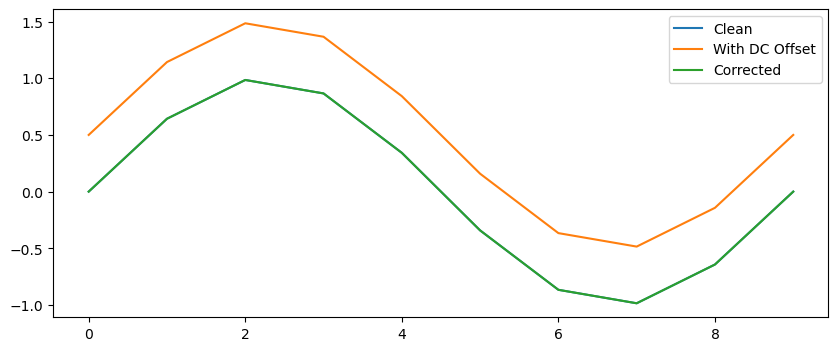

In [3]:

plt.figure(figsize=(10,4))

plt.plot(clean_signal, label="Clean")
plt.plot(offset_signal, label="With DC Offset")
plt.plot(corrected_signal, label="Corrected")

plt.legend()
plt.show()

In [4]:
#Short time Fourier Transform (STFT) example
import librosa
# Toy signal (8 samples)
x = np.array([0, 1, 0, -1, 0, 1, 0, -1], dtype=float)

print("Signal:", x)

window_size = 4
hop_size = 2

windows = []
for start in range(0, len(x) - window_size + 1, hop_size):
    segment = x[start:start + window_size]
    windows.append(segment)

windows = np.array(windows)
print("Windows:\n", windows)

Signal: [ 0.  1.  0. -1.  0.  1.  0. -1.]
Windows:
 [[ 0.  1.  0. -1.]
 [ 0. -1.  0.  1.]
 [ 0.  1.  0. -1.]]


In [5]:
stft_result = []

for w in windows:
    fft_vals = np.fft.fft(w)
    stft_result.append(fft_vals)

stft_result = np.array(stft_result)

print("STFT (complex values):\n", np.round(stft_result, 2))

magnitude = np.abs(stft_result)

print("Magnitude:\n", np.round(magnitude, 2))

STFT (complex values):
 [[0.+0.j 0.-2.j 0.+0.j 0.+2.j]
 [0.+0.j 0.+2.j 0.+0.j 0.-2.j]
 [0.+0.j 0.-2.j 0.+0.j 0.+2.j]]
Magnitude:
 [[0. 2. 0. 2.]
 [0. 2. 0. 2.]
 [0. 2. 0. 2.]]


In [8]:
#finding peaks in the spectrogram
import numpy as np

S = np.array([
    [1, 2, 1, 0],
    [2, 9, 3, 1],
    [1, 3, 8, 2],
    [0, 1, 2, 1]
])

print(S)
from scipy.ndimage import maximum_filter

local_max = maximum_filter(S, size=(3,3))
print(local_max)

peaks_mask = (S == local_max)
print(peaks_mask.astype(int))

[[1 2 1 0]
 [2 9 3 1]
 [1 3 8 2]
 [0 1 2 1]]
[[9 9 9 3]
 [9 9 9 8]
 [9 9 9 8]
 [3 8 8 8]]
[[0 0 0 0]
 [0 1 0 0]
 [0 0 0 0]
 [0 0 0 0]]
